In [40]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_curve,auc,roc_auc_score
from sklearn.impute import KNNImputer 
from sklearn.svm import SVC    
from sklearn.decomposition import PCA

In [25]:
iris = datasets.load_iris()

In [26]:
x = pd.DataFrame(iris.data,columns=iris.feature_names)

In [27]:
y = pd.DataFrame(iris.target, columns= ['categoty'])
y

,categoty
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [28]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [49]:
pc = PCA(n_components= 2)
x = pc.fit_transform(x,y)

In [52]:
x

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

ValueError: Shape of passed values is (150, 2), indices imply (150, 4)

In [53]:
x.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y ,test_size=0.3,random_state=42)

In [55]:
suport_vec = SVC()
df = suport_vec.fit(x_train,y_train)    

/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [56]:

y_pred = suport_vec.predict(x_test)



In [57]:
accuracy = accuracy_score(y_test, y_pred)

In [58]:
accuracy

0.9777777777777777

In [59]:
accuracy = accuracy_score(y_test, y_pred)

In [60]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



/tmp/ipykernel_37411/2471606983.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(x[:, 0], x[:, 1], edgecolors='k', cmap=plt.cm.Paired)
/home/prit.chavda@simform.dom/.local/lib/python3.8/site-packages/matplotlib/collections.py:1080: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


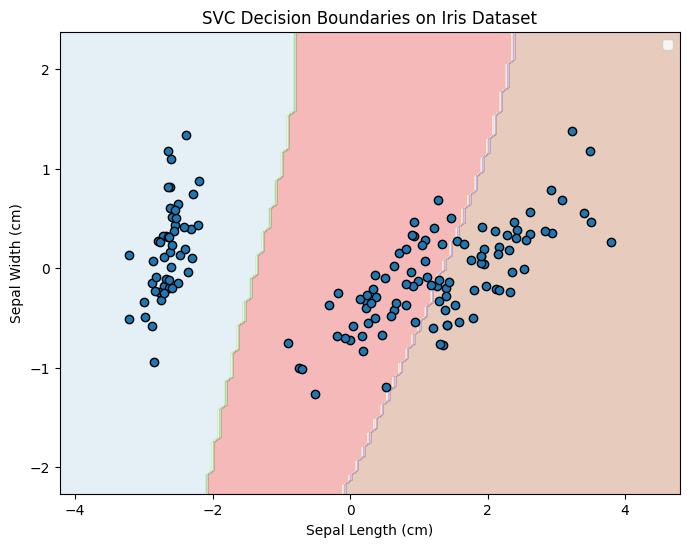

In [63]:
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), 
                     np.linspace(y_min, y_max, 100))

# Step 4: Predict on Meshgrid
Z = suport_vec.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 5: Plot decision boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)

# Step 6: Scatter plot the real data points
scatter = plt.scatter(x[:, 0], x[:, 1], edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('SVC Decision Boundaries on Iris Dataset')
plt.legend(handles=scatter.legend_elements()[0], labels=iris.target_names)
plt.show()